Importing Dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

 Step 1: Data Collection & Data Processing



In [2]:
# Loading dataset to Pandas Dataframe
meteorite_data = pd.read_csv('meteorite_landings.csv')
# Checking initial 5 rows of the data
meteorite_data.head()
# Summary of the data
meteorite_data.info()
# Using regex for removing all characters that are NOT a digit or a decimal point '.'
meteorite_data['Mass'] = meteorite_data['Mass'].str.replace(r'[^\d\.]', '', regex=True)

# Converting the cleaned strings to a numerical type
meteorite_data['Mass'] = pd.to_numeric(meteorite_data['Mass'], errors='coerce')
print(meteorite_data[['Mass']].describe())
meteorite_data['Year'] = meteorite_data['Year'].str.extract(r'(\d{4})')
meteorite_data['Year'] = pd.to_numeric(meteorite_data['Year'], errors='coerce')

# Extracting latitude and longitude from the 'Coordinates' column
meteorite_data[['reclat', 'reclong']] = meteorite_data['Coordinates'].str.extract(r'([-\d\.]+),\s*([-\d\.]+)').astype(float)
meteorite_data.head()
meteorite_data.dtypes
meteorite_data[['Mass', 'Year', 'reclat', 'reclong']].describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45716 entries, 0 to 45715
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Name            45716 non-null  object
 1   ID              45716 non-null  int64 
 2   NameType        45716 non-null  object
 3   Classification  45716 non-null  object
 4   Mass            45716 non-null  object
 5   Fall            45716 non-null  object
 6   Year            45716 non-null  object
 7   Coordinates     45716 non-null  object
dtypes: int64(1), object(7)
memory usage: 2.8+ MB
               Mass
count  4.558500e+04
mean   1.327808e+04
std    5.749889e+05
min    0.000000e+00
25%    7.200000e+00
50%    3.260000e+01
75%    2.026000e+02
max    6.000000e+07


,Mass,Year,reclat,reclong
count,4.558500e+04,45422.000000,32187.000000,32187.000000
mean,1.327808e+04,1991.874928,-46.675559,72.854090
std,5.749889e+05,23.956664,47.049897,83.055587
min,0.000000e+00,1399.000000,-87.366670,-165.433330
25%,7.200000e+00,1987.000000,-79.683330,26.000000
50%,3.260000e+01,1998.000000,-72.000000,56.646250
75%,2.026000e+02,2003.000000,18.536165,159.386110
max,6.000000e+07,2013.000000,81.166670,178.200000


Step 2: Data Cleaning and Preparation

In [3]:
# Checking for the null values if any
meteorite_data.isnull().sum()

# Dropping the rows which have null values or Nan if any
meteorite_data.dropna(subset=['Mass', 'Year', 'reclat', 'reclong'], inplace=True)

# Rechecking for null values
meteorite_data.isnull().sum()

# Checking for Mass data which has still 0 except Nan
zero_mass_count = (meteorite_data['Mass'] == 0).sum()
print(f"Number of rows with zero mass: {zero_mass_count}")

# Checking for Year data which has still 0 except Nan
zero_year_count = (meteorite_data['Year'] == 0).sum()
print(f"Number of rows with zero year: {zero_year_count}")

# Checking the number of rows before cleaning
print(f"Shape before removing zeros: {meteorite_data.shape}")
meteorite_data = meteorite_data[(meteorite_data['Mass']>0) & (meteorite_data['Year']>0)]

# Checking the number of rows after cleaning
print(f"Shape after removing zeros: {meteorite_data.shape}")

# Conversion from grams to Kg
meteorite_data['mass_kg'] = meteorite_data['Mass'] / 1000

# Printing first 5 rows after all the processes
meteorite_data.head()

Number of rows with zero mass: 18
Number of rows with zero year: 0
Shape before removing zeros: (31928, 10)
Shape after removing zeros: (31910, 10)


,Name,ID,NameType,Classification,Mass,Fall,Year,Coordinates,reclat,reclong,mass_kg
0,Aachen,1,Valid,L5,21.0,Fell,1880.0,"GeoPosition[{50.775, 6.08333}]",50.77500,6.08333,0.021
1,Aarhus,2,Valid,H6,720.0,Fell,1951.0,"GeoPosition[{56.18333, 10.23333}]",56.18333,10.23333,0.720
2,Abee,6,Valid,EH4,107000.0,Fell,1952.0,"GeoPosition[{54.21667, -113.}]",54.21667,-113.00000,107.000
3,Acapulco,10,Valid,Acapulcoite,1914.0,Fell,1976.0,"GeoPosition[{16.88333, -99.9}]",16.88333,-99.90000,1.914
4,Achiras,370,Valid,L6,780.0,Fell,1902.0,"GeoPosition[{-33.16667, -64.95}]",-33.16667,-64.95000,0.780


Step 3: Detective Work

In [ ]:
# To find heaviest meteorite we will use Sort algo for mass_kg/Mass column
heaviest_10_meteorites = meteorite_data.sort_values(by='mass_kg', ascending=False).head(10)
print(heaviest_10_meteorites)
clean=pd.read_csv('meteorite_landings.csv')
# 1. Convert 'year' to numeric
meteorite_data['Year'] = pd.to_numeric(clean['Year'], errors='coerce')

# 2. Drop rows with missing years (optional)
clean = clean.dropna(subset=['Year'])

# 3. Create decade column
clean['decade'] = (clean['Year'] // 10) * 10

# 4. Verify the column exists
print(clean[['Year', 'decade']].head())

# 5. Now group by decade
decade_counts = clean.groupby('decade').size().reset_index(name='count').sort_values('decade')
print(decade_counts)


# To find Count of Fell vs Found Meteorite
fell_vs_found = meteorite_data['Fall'].value_counts()
print(fell_vs_found)

# Finding Average mass for most common classifiaction
common_classification = meteorite_data['Classification'].value_counts().idxmax()    # First count all classification and then find highest count classifiaction
average_mass_common_classification = meteorite_data[meteorite_data['Classification'] == common_classification]['mass_kg'].mean()
print(average_mass_common_classification)

# Grouping data for time based analysis
decade= (clean['Year']//10)*10
print(clean[['Year', 'decade']].head())

# Grouping by the new 'decade' column and count the number of entries in each group
decade_counts = clean.groupby('decade').size()

# Display the results
print("\nNumber of meteorites discovered per decade:")
print(decade_counts)

# Numpy Opeartions

# 1] Calculating Mean
mean_meteorite = meteorite_data['mass_kg'].mean()
print(mean_meteorite)

# 2] Calculating Median
median_meteorite = meteorite_data['mass_kg'].median()
print(median_meteorite)

# 3] Calculating Std
std_meteorite = meteorite_data['mass_kg'].std()
print(std_meteorite)

# 4] Calculating Sum
sum_meteorite =meteorite_data['mass_kg'].sum()
print(sum_meteorite)

# 5] Calculating Max
max_meteorite = meteorite_data['mass_kg'].max()
print(max_meteorite)


                        Name     ID NameType   Classification        Mass  \
16392                   Hope  11890    Valid        Iron, IVB  60000000.0   
5373            Catalina 011   5262    Valid      Iron, IIIAB  58200000.0   
5365            Catalina 003   5247    Valid     Iron, IAB-MG  50000000.0   
5370            Catalina 008   5257    Valid     Iron, IAB-MG  30000000.0   
3455              Asuka 8602   2335    Valid       Iron, IIIE  28000000.0   
12613      Glorieta Mountain  10912    Valid        Iron, IVA  26000000.0   
5468        Colorado Springs   5363    Valid      Iron, IIIAB  24300000.0   
26297        Mundrabilla 005  16852    Valid    Iron, IAB-ung  24000000.0   
920                    Sinai  23593    Valid       Iron, IIAB  23000000.0   
5016   Bates Nunataks A78005   4919    Valid  Iron, ungrouped  22000000.0   

        Fall    Year                          Coordinates    reclat  \
16392  Found  1920.0   GeoPosition[{-19.58333, 17.91667}] -19.58333   
5373   Fou

Step 4: Visualization

IndexError: index 0 is out of bounds for axis 0 with size 0

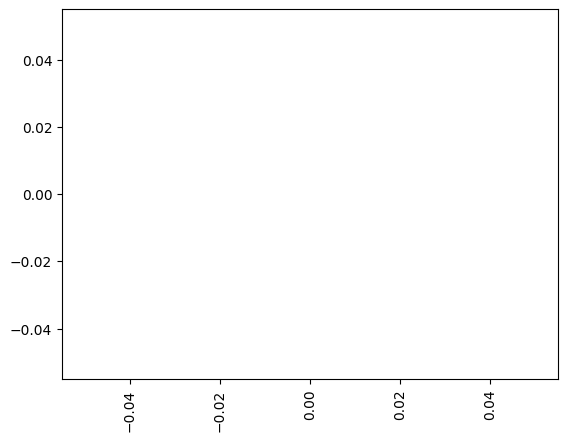

In [ ]:
# 1] 'When' Discovery for Time

plt.plot(decade_counts.index, decade_counts)
plt.xlabel('Decade')
plt.ylabel('Number of Meteorites')
plt.title('Number of Meteorites Discovered per Decade')
plt.show()

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the column is consistent
if 'fall' in meteorite_data.columns:
    # Normalize text (some datasets have 'Fell', 'fell', 'FOUND', etc.)
    meteorite_data['fall'] = meteorite_data['fall'].str.strip().str.capitalize()

    # Count occurrences
    fall_counts = meteorite_data['fall'].value_counts()

    # Plot
    plt.figure(figsize=(6,4))
    sns.barplot(x=fall_counts.index, y=fall_counts.values, palette='viridis')

    plt.title('Meteorite Recovery Method: Fell vs Found', fontsize=14)
    plt.xlabel('Recovery Type')
    plt.ylabel('Count of Meteorites')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No 'fall' column found in the dataset.")


⚠️ No 'fall' column found in the dataset.


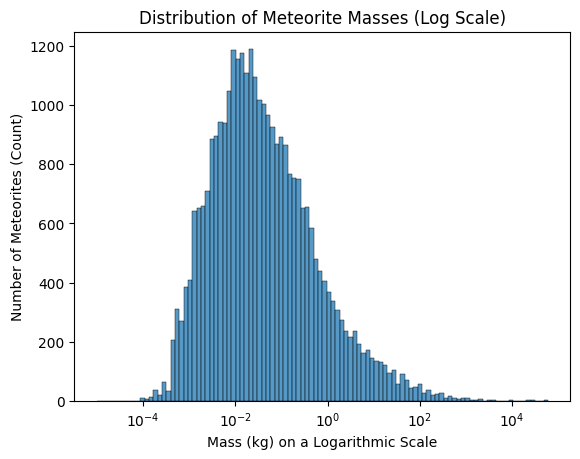

In [20]:
# 2] Mass Ditribution
sns.histplot(data=meteorite_data, x='mass_kg', log_scale=True)
plt.title('Distribution of Meteorite Masses (Log Scale)')
plt.xlabel('Mass (kg) on a Logarithmic Scale')
plt.ylabel('Number of Meteorites (Count)')
plt.show()

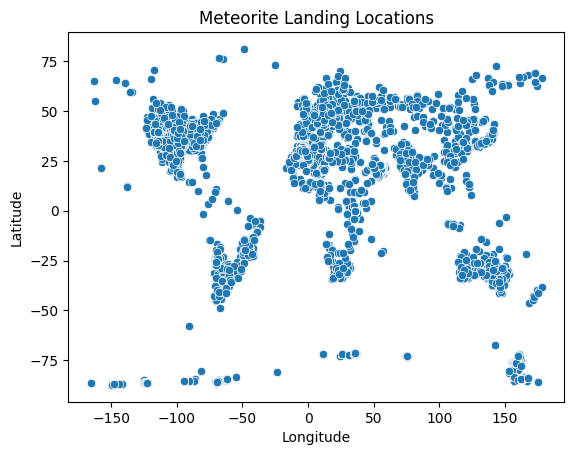

In [21]:
# 3] Landing Locations
sns.scatterplot(data=meteorite_data, x='reclong', y='reclat')
plt.title('Meteorite Landing Locations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()